In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from scipy import optimize

In [ ]:
df_1 = pd.read_excel(r"vendor1.xlsx")
df_2 = pd.read_excel(r"vendor2.xlsx")
df_1.info(), df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  35 non-null     int64  
 1   YS           35 non-null     float64
 2   Mpa          35 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 972.0 bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  48 non-null     int64  
 1   YS           48 non-null     float64
 2   Mpa          48 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 1.3 KB


(None, None)

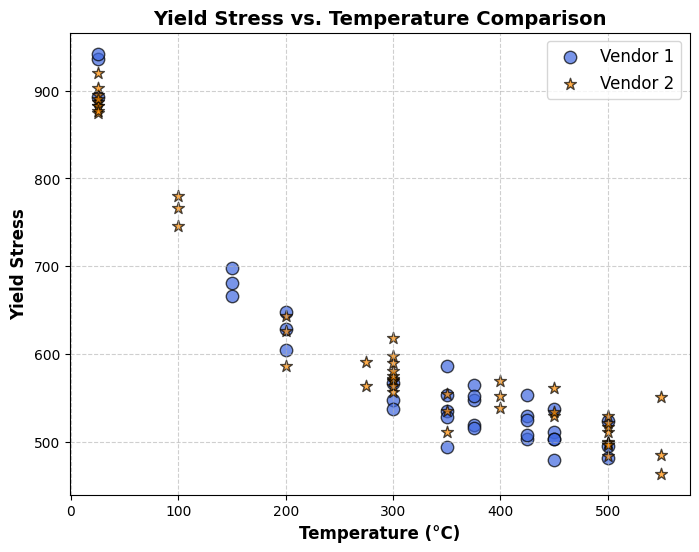

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(df_1["Temperature"], df_1["Mpa"], color='royalblue', edgecolors='black', alpha=0.7, s=80, label="Vendor 1")
plt.scatter(df_2["Temperature"], df_2["Mpa"], marker='*', color='darkorange', edgecolors='black', alpha=0.7, s=80, label="Vendor 2")

plt.xlabel("Temperature (°C)", fontsize=12, fontweight='bold')
plt.ylabel("Yield Stress", fontsize=12, fontweight='bold')
plt.title("Yield Stress vs. Temperature Comparison", fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(fontsize=12)

plt.show()

In [4]:
data = pd.concat([df_1, df_2], ignore_index=True)
data_sorted = data.sort_values(by="Temperature", ascending=True)
df_3 = data_sorted.reset_index(drop=True)
df_3.head(10)

,Temperature,YS,Mpa
0,25,1.04164,935.996871
1,25,1.04832,941.999386
2,25,0.99379,892.999818
3,25,0.97376,875.001261
4,25,0.98711,886.997304
5,25,0.98155,882.001199
6,25,0.99602,895.003652
7,25,0.99045,889.998561
8,25,1.00492,903.001014
9,25,1.02384,920.002147


In [5]:
df_dict = {temp: df_3[df_3["Temperature"] == temp].reset_index(drop=True) for temp in df_3["Temperature"].unique()}

df_dict[550]

,Temperature,YS,Mpa
0,550,0.61319,551.000270
1,550,0.51637,463.999755
2,550,0.53974,484.999569


In [6]:
# Arrhenius Transform
data_sorted['Inverse_Temp'] = 11604.53 / (data_sorted['Temperature'] + 273.16)  # Convert to Kelvin
data_sorted['Ln_Mpa'] = np.log(data_sorted['Mpa'])  # Log transformation

In [7]:
X_values = data_sorted['Inverse_Temp'].values
Y_values = data_sorted['Mpa'].values

In [20]:
from scipy.special import exp1

def gumbel_log_likelihood(params, x, y):
    mu = params[0]           # Intercept
    beta1 = params[1]        # Slope
    sigma = params[2]        # Scale

    if sigma <= 0:
        return np.inf
    
    loc = mu + beta1 * x
    z = (y - loc) / sigma
    z = np.clip(z, -700, 700)  # -exp(-z) overflows around -745
    logpdf = -z - np.exp(-z) - np.log(sigma)
    return -np.sum(logpdf)

In [23]:
# Initial guess: [intercept, slope, scale]
init_params = [np.mean(Y_values), 0.0, np.std(Y_values)]
bounds = [(None, None), (None, None), (1e-6, None)]

result_gumbel = optimize.minimize(
    gumbel_log_likelihood,
    init_params,
    args=(X_values, Y_values),
    bounds=bounds,
    method="L-BFGS-B"
)

u, w, sigma = result_gumbel.x

print(f"Intercept (u): {u:.4f}")
print(f"Slope (w): {w:.4f}")
print(f"Gumbel Scale (sigma): {sigma:.4f}")

Intercept (u): 376.0743
Slope (w): 9.8249
Gumbel Scale (sigma): 24.7814


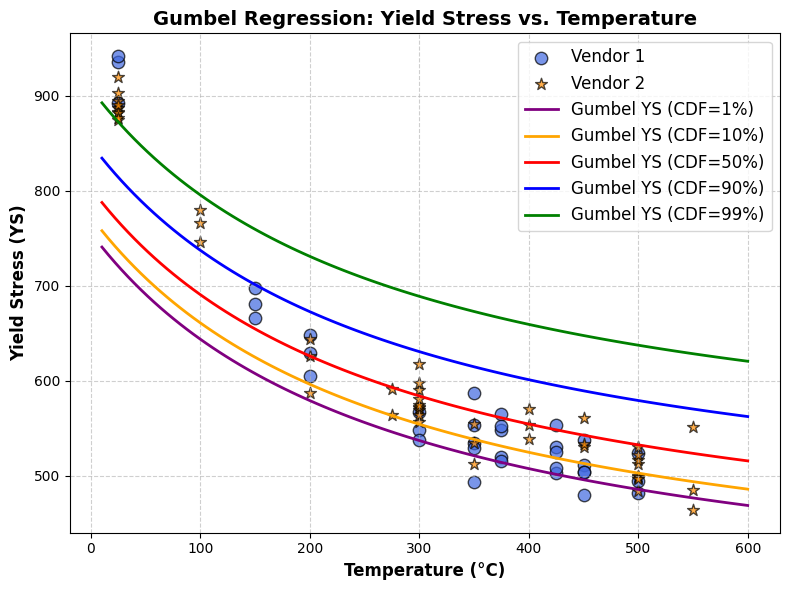

In [24]:
temperature_values = np.linspace(10, 600, 100)
inv_temp = 11604.53 / (temperature_values + 273.16)

cdf_levels = {
    "CDF=1%": 0.01,
    "CDF=10%": 0.10,
    "CDF=50%": 0.50,
    "CDF=90%": 0.90,
    "CDF=99%": 0.99
}

ys_predictions = {
    label: u + w * inv_temp - sigma * np.log(-np.log(cdf))
    for label, cdf in cdf_levels.items()
}


plt.figure(figsize=(8, 6))

# Original data
plt.scatter(df_1["Temperature"], df_1["Mpa"], color='royalblue', edgecolors='black', s=80, alpha=0.7, label="Vendor 1")
plt.scatter(df_2["Temperature"], df_2["Mpa"], color='darkorange', edgecolors='black', marker='*', s=80, alpha=0.7, label="Vendor 2")

# Prediction lines
colors = ["purple", "orange", "red", "blue", "green"]
for (label, ys), color in zip(ys_predictions.items(), colors):
    plt.plot(temperature_values, ys, color=color, linewidth=2, label=f"Gumbel YS ({label})")

# Labels and styling
plt.xlabel("Temperature (°C)", fontsize=12, fontweight="bold")
plt.ylabel("Yield Stress (YS)", fontsize=12, fontweight="bold")
plt.title("Gumbel Regression: Yield Stress vs. Temperature", fontsize=14, fontweight="bold")
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

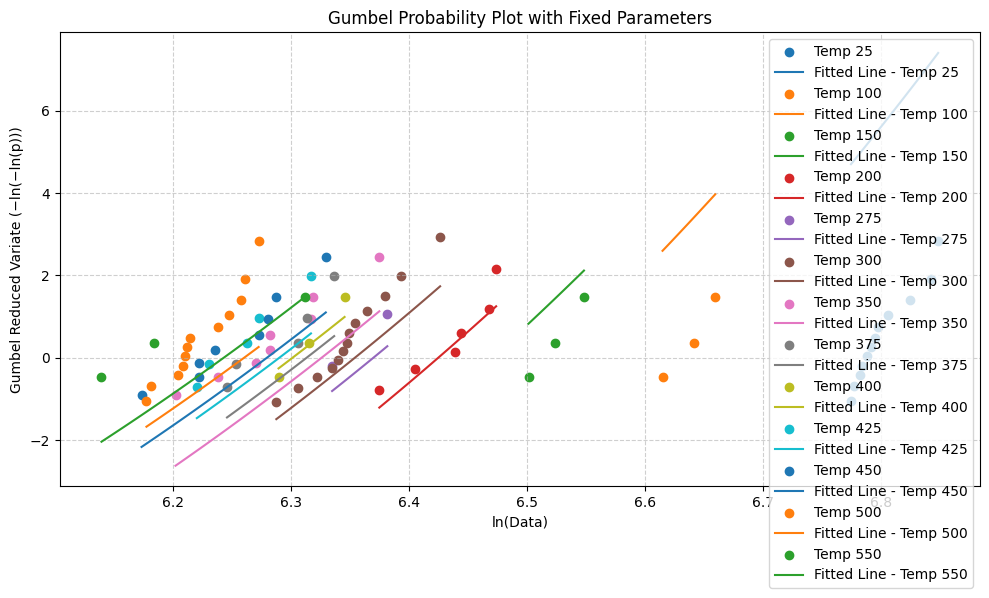

In [25]:
def median_rank(n, i):
    return (i - 0.3) / (n + 0.4)

plt.figure(figsize=(10, 6))

# Gumbel parameters (from your regression)
u_fixed = u
w_fixed = w
sigma_fixed = sigma

for temp in df_dict.keys():
    data = df_dict[temp]["Mpa"].values
    data = np.sort(data)

    n = len(data)
    p_values = np.array([median_rank(n, i + 1) for i in range(n)])

    # Gumbel probability axis transformation
    x_values = data
    y_values = -np.log(-np.log(p_values))  # Reduced variate Y

    plt.scatter(np.log(x_values), y_values, label=f"Temp {temp}")

    # Predicted location (mean)
    inv_temp = 11604.53 / (temp + 273.16)
    mu = u_fixed + w_fixed * inv_temp

    # Generate prediction line
    x_fit = np.linspace(min(data), max(data), 100)
    p_fit = stats.gumbel_r.cdf(x_fit, loc=mu, scale=sigma_fixed)
    y_fit = -np.log(-np.log(p_fit))

    plt.plot(np.log(x_fit), y_fit, linestyle='-', label=f"Fitted Line - Temp {temp}")

plt.title("Gumbel Probability Plot with Fixed Parameters")
plt.xlabel("ln(Data)")
plt.ylabel("Gumbel Reduced Variate (−ln(−ln(p)))")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()